In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [163]:
df_deliveries = pd.read_csv('CSV/deliveries.csv')
df_matches = pd.read_csv('CSV/matches.csv')

In [164]:
teams = [
    'Sunrisers Hyderabad', 'Mumbai Indians', 'Royal Challengers Bengaluru',
    'Kolkata Knight Riders', 'Punjab Kings', 'Chennai Super Kings',
    'Rajasthan Royals', 'Delhi Capitals', 'Gujarat Titans', 'Lucknow Super Giants'
]

In [165]:
name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

for col in ['team1', 'team2', 'winner']:
    df_matches[col] = df_matches[col].replace(name_map)


for col in ['batting_team', 'bowling_team']:
    df_deliveries[col] = df_deliveries[col].replace(name_map)


In [166]:
df_matches = df_matches[df_matches['team1'].isin(teams)]
df_matches = df_matches[df_matches['team2'].isin(teams)]

df_deliveries = df_deliveries[df_deliveries['batting_team'].isin(teams)]
df_deliveries = df_deliveries[df_deliveries['bowling_team'].isin(teams)]


In [167]:
df_matches = df_matches[df_matches['method'].isna()]

In [168]:
df_matches['venue_clean'] = (
    df_matches['venue']
    .str.strip()
    .str.lower()
    .str.split(",").str[0]
)

In [169]:
venue_mapping = {
    # Delhi
    "feroz shah kotla": "arun jaitley stadium",
    "arun jaitley stadium": "arun jaitley stadium",

    # Ahmedabad
    "sardar patel stadium": "narendra modi stadium",
    "motera": "narendra modi stadium",
    "narendra modi stadium": "narendra modi stadium",

    # Mohali
    "punjab cricket association stadium": "punjab cricket association is bindra stadium",
    "punjab cricket association is bindra stadium": "punjab cricket association is bindra stadium",

    # Pune
    "subrata roy sahara stadium": "maharashtra cricket association stadium",
    "maharashtra cricket association stadium": "maharashtra cricket association stadium",

    # Abu Dhabi
    "sheikh zayed stadium": "zayed cricket stadium",
    "zayed cricket stadium": "zayed cricket stadium",

    # Chennai
    "ma chidambaram stadium": "ma chidambaram stadium",

    # Mumbai
    "wankhede stadium": "wankhede stadium",
    "brabourne stadium": "brabourne stadium",
    "dr dy patil sports academy": "dr dy patil sports academy",

    # Hyderabad
    "rajiv gandhi international stadium": "rajiv gandhi international stadium",

    # Visakhapatnam
    "dr. y.s. rajasekhara reddy aca-vdca cricket stadium": "dr. y.s. rajasekhara reddy aca-vdca cricket stadium",

    # Jaipur
    "sawai mansingh stadium": "sawai mansingh stadium",

    # Nagpur
    "vidarbha cricket association stadium": "vidarbha cricket association stadium",

    # Lucknow
    "bharat ratna shri atal bihari vajpayee ekana cricket stadium": "bharat ratna shri atal bihari vajpayee ekana cricket stadium",

    # Ranchi
    "jsca international stadium complex": "jsca international stadium complex",

    # Raipur
    "shaheed veer narayan singh international stadium": "shaheed veer narayan singh international stadium",

    # Indore
    "holkar cricket stadium": "holkar cricket stadium",

    # Bangalore
    "m chinnaswamy stadium": "m chinnaswamy stadium",

    # Kolkata
    "eden gardens": "eden gardens",

    # International (South Africa / UAE)
    "newlands": "newlands",
    "kingsmead": "kingsmead",
    "supersport park": "supersport park",
    "st george's park": "st george's park",
    "new wanderers stadium": "new wanderers stadium",
    "buffalo park": "buffalo park",
    "outsurance oval": "outsurance oval",
    "de beers diamond oval": "de beers diamond oval",
    "barsapara cricket stadium": "barsapara cricket stadium",
    "sharjah cricket stadium": "sharjah cricket stadium",
    "dubai international cricket stadium": "dubai international cricket stadium",
    "maharaja yadavindra singh international cricket stadium": "maharaja yadavindra singh international cricket stadium",
}


In [170]:
df_matches['venue_clean'] = (
    df_matches['venue_clean']
    .str.strip().str.lower()
    .replace(venue_mapping)
)


In [171]:
df_matches.drop('venue', axis=1,inplace=True)
df_matches.rename(columns={'venue_clean':'venue'},inplace=True)

In [172]:
df_matches = df_matches[['id','venue','winner','target_runs']]

In [173]:
df_matches.rename(columns={'id' : 'match_id'},inplace=True)

In [174]:
print(df_matches['match_id'].nunique())
print(df_deliveries['match_id'].nunique())

963
980


In [175]:
delivery = df_matches.merge(df_deliveries, on='match_id')

In [176]:
first_inning = delivery[delivery['inning'] == 1]

per_match_1st = (
    first_inning.groupby(['batter', 'match_id']).agg(
        runs_in_match=('batsman_runs', 'sum'),
        balls_in_match=('ball', 'count')
    )
    .reset_index()
)
per_match_1st = per_match_1st.sort_values(['batter','match_id'])

per_match_1st['overall_runs'] = (
    per_match_1st.groupby('batter')['runs_in_match']
    .transform(lambda x: x.cumsum().shift(fill_value=0))
)
per_match_1st['overall_balls'] = (
    per_match_1st.groupby('batter')['balls_in_match']
    .transform(lambda x: x.cumsum().shift(fill_value=0))
)

per_match_1st['overall_SR'] = ((per_match_1st['overall_runs'] / per_match_1st['overall_balls']) * 100).round(2)

In [177]:
per_match_1st['overall_SR'] = per_match_1st['overall_SR'].fillna(0)

In [178]:
per_match_1st[per_match_1st['batter'] == 'AB de Villiers']

,batter,match_id,runs_in_match,balls_in_match,overall_runs,overall_balls,overall_SR
152,AB de Villiers,336009,0,1,0,0,0.00
153,AB de Villiers,336015,20,23,0,1,0.00
154,AB de Villiers,392189,105,54,20,24,83.33
155,AB de Villiers,392198,50,41,125,78,160.26
156,AB de Villiers,392223,44,36,175,119,147.06
...,...,...,...,...,...,...,...
226,AB de Villiers,1254087,0,1,2753,1766,155.89
227,AB de Villiers,1254090,23,18,2753,1767,155.80
228,AB de Villiers,1254108,11,7,2776,1785,155.52
229,AB de Villiers,1254113,12,11,2787,1792,155.52


In [179]:
delivery = delivery[delivery['inning'] == 2]

In [180]:
delivery['current_score'] = delivery.groupby('match_id')['total_runs'].cumsum()

In [181]:
delivery['runs_left'] =  delivery['target_runs'] - delivery['current_score']

In [182]:
delivery['balls_left'] =  120 - (delivery['over'] * 6 + delivery['ball'])

In [183]:
wickets = delivery.groupby('match_id')['is_wicket'].cumsum()
delivery['wickets_left'] = 10 - wickets

In [184]:
delivery['crr'] = delivery['current_score'] * 6 / (120- delivery['balls_left'])

In [185]:
delivery['rrr'] = delivery['runs_left'] * 6 / delivery['balls_left']

In [186]:
def result(row):
    return 1 if row['batting_team'] == row['winner'] else 0

In [187]:
delivery['result'] = delivery.apply(result,axis=1)

In [188]:
valid_balls = delivery[delivery['extras_type'].isna() | 
                       delivery['extras_type'].isin(['legbyes', 'byes', 'noballs'])]


In [189]:
per_match = (
    delivery.groupby(['batter', 'match_id']).agg(
        runs_in_match=('batsman_runs', 'sum'),
        balls_in_match=('ball', 'count')
    )
    .reset_index()
)


In [190]:
per_match = per_match.sort_values(['batter','match_id'])

In [191]:
per_match['overall_runs'] = (
    per_match.groupby('batter')['runs_in_match']
    .transform(lambda x: x.cumsum().shift(fill_value=0))
)
per_match['overall_balls'] = (
    per_match.groupby('batter')['balls_in_match']
    .transform(lambda x: x.cumsum().shift(fill_value=0))
)


In [192]:
per_match['overall_SR'] = ((per_match['overall_runs'] / per_match['overall_balls']) * 100).round(2)

In [193]:
per_match["last5_runs"] = (
    per_match.groupby("batter")["runs_in_match"]
    .transform(lambda x: x.shift(fill_value = 0).rolling(5, min_periods=1).sum())
)

per_match["last5_balls"] = (
    per_match.groupby("batter")["balls_in_match"]
    .transform(lambda x: x.shift(fill_value = 0).rolling(5, min_periods=1).sum())
)


In [194]:
per_match['last5_SR'] = ((per_match['last5_runs'] / per_match['last5_balls']) * 100).round(2)

In [195]:
per_match[['overall_SR','last5_SR']] = per_match[['overall_SR','last5_SR']].fillna(0)

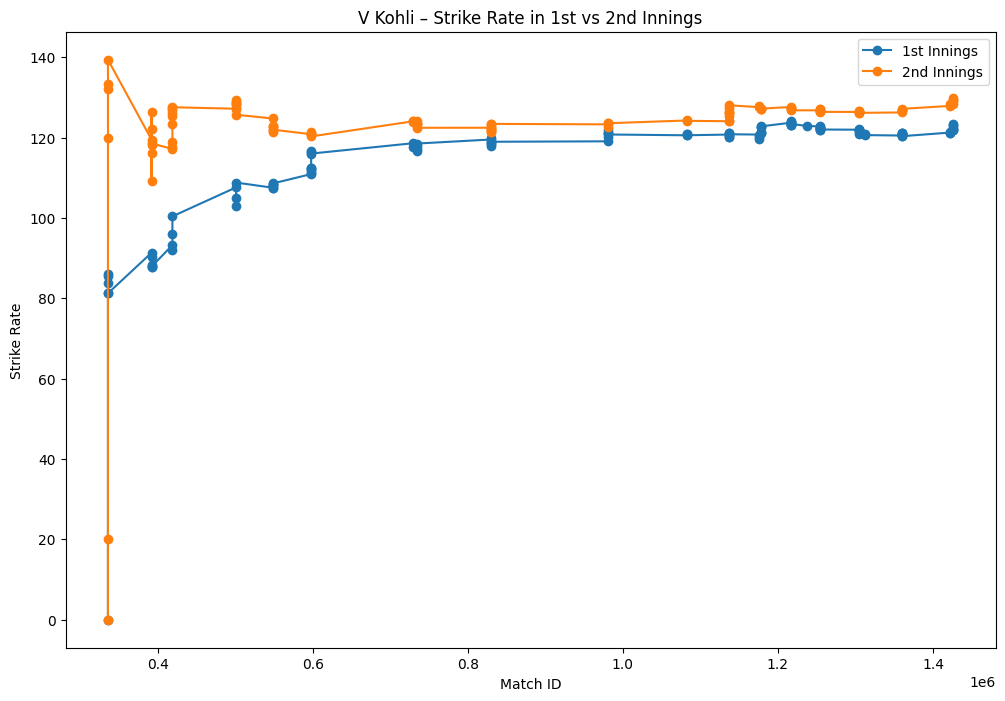

In [203]:
player = "V Kohli"

df1 = per_match_1st[per_match_1st["batter"] == player].sort_values("match_id")
df2 = per_match[per_match["batter"] == player].sort_values("match_id")

plt.figure(figsize=(12,8))
plt.plot(df1["match_id"], df1["overall_SR"], marker="o", label="1st Innings")
plt.plot(df2["match_id"], df2["overall_SR"], marker="o", label="2nd Innings")
plt.ylabel("Strike Rate")
plt.xlabel("Match ID")
plt.title(f"{player} – Strike Rate in 1st vs 2nd Innings")
plt.legend()


In [ ]:
per_match['batter'].value_counts()

batter
RG Sharma      114
V Kohli        108
KD Karthik      93
DA Warner       88
S Dhawan        86
              ... 
A Uniyal         1
A Mukund         1
VS Yeligati      1
VS Malik         1
A Chopra         1
Name: count, Length: 594, dtype: int64

In [ ]:
final_df = delivery[['match_id','batting_team','bowling_team','venue','runs_left','balls_left','wickets_left','target_runs','crr','rrr','result']]

In [ ]:
final_df = final_df[final_df['balls_left'] != 0]

In [ ]:
final_df.dropna(subset=['rrr'],inplace=True)

In [ ]:
final_df.columns

Index(['match_id', 'batting_team', 'bowling_team', 'venue', 'runs_left',
       'balls_left', 'wickets_left', 'target_runs', 'crr', 'rrr', 'result'],
      dtype='object')

In [ ]:
print(final_df.head(1))

     match_id                 batting_team           bowling_team  \
124    335982  Royal Challengers Bengaluru  Kolkata Knight Riders   

                     venue  runs_left  balls_left  wickets_left  target_runs  \
124  m chinnaswamy stadium      222.0         119            10        223.0   

     crr        rrr  result  
124  6.0  11.193277       0  


In [ ]:
def phase_and_progress(row, total_overs=20):
    balls_bowled = total_overs*6 - row['balls_left']
    
    if row['balls_left'] <= 30:
        phase = 'death_over'
    elif row['balls_left'] >= 84:
        phase = 'powerplay'
    else:
        phase = 'middle_over'
    
    overs_completed = balls_bowled / 6
    
    return pd.Series([phase, overs_completed], index=['phase', 'overs_completed'])

In [ ]:
final_df[['current_phase','over_completed']] = final_df.apply(phase_and_progress, axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
unique_matches = final_df['match_id'].unique()
train_matches, test_matches = train_test_split(
    unique_matches, test_size=0.2, random_state=2
)

In [ ]:
train_data = final_df[final_df['match_id'].isin(train_matches)]
test_data = final_df[final_df['match_id'].isin(test_matches)]

In [ ]:
train_data['match_id'].value_counts().sort_values()

match_id
1178424     20
1082626     49
598068      50
1136608     51
1254093     53
          ... 
1426288    131
1426268    132
829811     133
829737     133
1359480    135
Name: count, Length: 768, dtype: int64

In [ ]:
test_data['match_id'].value_counts().sort_values()

match_id
829813       7
336021      38
1304082     49
829803      63
1254087     65
          ... 
392190     129
1426294    130
1216522    130
829777     130
1370350    131
Name: count, Length: 193, dtype: int64

In [ ]:
train_data = train_data.sample(frac = 1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac = 1, random_state=42).reset_index(drop=True)

In [ ]:
X_train = train_data.drop(columns=['result','match_id'])
y_train = train_data['result']

X_test = test_data.drop(columns=['result','match_id'])
y_test = test_data['result']

In [ ]:
trf = ColumnTransformer(
    transformers=[
        ('trf', OneHotEncoder(sparse_output=False, drop='first'), ['batting_team', 'bowling_team', 'venue'])
    ], remainder='passthrough'
)

In [ ]:
pipe = Pipeline(steps=[
    ('step1',trf),
    ('step2',LogisticRegression(solver='liblinear'))
])